# Harmonized Landsat-Sentinel (HLS) Reflectance

### Missouri River Cottonwoods

In this notebook, we demonstrate how to access, visualize, and analyze HLS data directly from NASA Earthaccess. We place emphasis on the different modes of data access (cloud streaming and downloading locally) and demonstrate the application of CARE principles throughout the notebook. Our case study is focused on the riparian corridor of the Missouri River in Pine Ridge, SD, with a focus on cottonwood gallaries. HLS time-series, spectral indices, and textural features are used to characterize cottonwood along the river.

In [13]:
import os
import geopandas as gpd
import earthaccess
from pathlib import Path

# This will ignore some warnings caused by holoviews
import warnings
warnings.simplefilter('ignore')

print(os.getcwd())
maindir = Path(os.getcwd()).parent

auth = earthaccess.login()
earthaccess.login(persist=True)

print("Ready to go !")

/Users/max/Library/CloudStorage/OneDrive-Personal/mcook/esiil/Public-Observing-Unci-Maka/notebooks
Ready to go !


<Axes: >

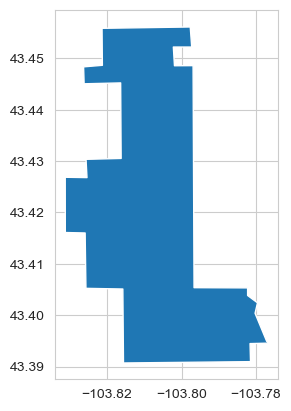

In [14]:
# load the craven canyon study site
fp = os.path.join(maindir, 'data/CravenCanyon_StudyArea.gpkg')
aoi = gpd.read_file(fp)
aoi.plot()

<Axes: >

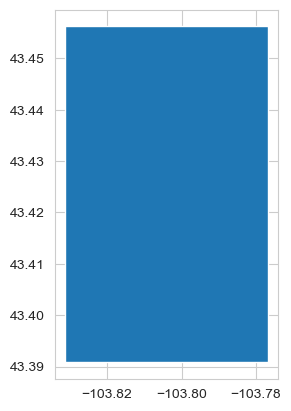

In [17]:
# make a bounding box
bounds = aoi.envelope
bounds.plot()

In [18]:

bbox_poly = box(*bounds.total_bounds)  # order is (minx, miny, maxx, maxy)


array([-103.83130876,   43.39079223, -103.77694398,   43.45622087])

In [ ]:
granules = earthaccess.search_data(
    short_name="HLSS30",  # Sentinel-2 in HLS
    bounding_box=bounding_box,
    temporal=(first_date, last_date),
    cloud_hosted=True
)
print(f"Found {len(granules)} HLS Sentinel-2 granules")